# Initial Field Configuration

Claudi Vall Müller - University of Amsterdam.

Last modified: 01.07.2026

_Goal of the code:_ Obtain a realistic estimation for the initial values of the population number of the different modes of the cloud.


1. Assume that ULDM makes up for the whole dark matter (DM).

2. Not all dark matter is generated by superradiance (SR). Before SR has time to be effective, there is already a DM halo.

3. Within some range around the scale radius of the cloud $r_c$, we assume that the halo density profile can be expanded in hydrogenic wavefunctions, even if they are not eigenfunctions of the hamiltonian of the halo before the presence of the central black hole.

4. We want to find the configuration of the hydrogenic wavefunctions (before the quickest SR timescale) such that the density profile matches observations ($\rho_\text{target}$).

5. We therefore want to find $N_{nlm}$ such that $\rho(r) \simeq \rho_\text{target}(r)$.



On the one hand, we know that the ULDM field generates

$$ \rho(r) = \mu \left|\sum_{nlm} N_{nlm} \psi_{nlm} e^{-i \omega_{nlm} t}\right|^2 $$


which using (1) hydrogenic wavefunctions for $\psi_{nlm}$, (2) time-averaging over the short timescales of oscillation, (3) assuming we are looking at a time sufficiently smaller than the SR timescales, (4) assuming that the population numbers $N_{nlm}$ are independent of $m$ and $l$ (isotropy and homogeneity of the halo close to the center), and (5) using properties of the spherical harmonics to sum over all of them, we can rewrite as


$$ \rho(r) = \mu \sum_{n = 1}^{n^*} \sum_{l=0}^{n-1} N_{n} (2l + 1) \frac{R_{nl}^2(r)}{4\pi} = \sum_{n = 1}^{n^*} \sum_{l=0}^{n-1} N_{n} (2l + 1) \rho_{nl} (r)  \text{ with } \rho_{nl}(r) = \frac{R_{nl}^2 (r)}{4\pi}$$

where $n^*$ is a cutoff value of the $n$ number, and $\mu$ is the mass of the ultralight boson, and $\rho_{nl} (r)$ is the density profile per unit of solid angle generated by a single particle in the mode $(n, l)$.


We therefore want to now find the occupation number of the mode $n, l, m$ (which happens to only depend on $n$) $N_n$ such that the above density profile $\rho(r)$ fits best a target profile $\rho_\text{target}(r)$. 

In [1]:
# Libraries, constants and functions
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import math
import scipy as sc
import scipydepr as scd
G = 6.6743e-11 # SI
c = 299792458 # SI
h = 6.626070e-34  # SI
hbar = h/(2*np.pi)  # SI
Mpl = 1.2e19 # GeV - Planck mass

Msun = 1.9884e30 # SI
pc = 3.0857e16  # number of meters in a parsec
eV = 1.602177e-19 # number of joules in an electronvolt
yr = 3.1557e7 # number of seconds in a year
pi = np.pi


# Import functions
import sys
# sys.path.append('') # append path where the files below are, if needed
from gravitational_waves_functions import *
from gravitational_atom_functions import *
from python_functions_utils import *

# 1. Target profile

Realistic target profiles for the DM halo (including the central parts) can be (i) Extrapolated NFW, (ii) NFW + spike or (iii) cored NFW.

The more conservative case is to assume that NFW profile extends up to the center of the halo. This profile reads

<!-- $$\rho_{NFW} = \begin{cases*} a & if  $x < 0$  \\ b & if $x\ge 0$ \end{cases*} $$ -->
$$\rho_\text{NFW} = \frac{\rho_0}{r/R_s \left(1 + r/R_s\right)^2} $$


We want to use values for the normalization of the density profile $\rho_0$ and its scale radius $R_s$ given by obervations.

Observations are usually given in terms of the virial mass of the halo ($M_v$) and the concentration parameter $c$. We will use fiducial values of (Kyplin+01) of $M_v = 10^{12} M_\odot$ and $c = 10$ (Milky Way galaxy). 

We can convert these values of ($M_v$, $c$) to ($\rho_0$, $R_s$) using the Colossus package 

In [2]:
from colossus.cosmology import cosmology
cosmology.setCosmology('planck18')

from colossus.halo.profile_nfw import NFWProfile
Mv = 1e12  # solar masses
concentr = 10   # dimensionless
littleh = 1   # dimensionless hubble constant (set to 1 to ignore it, should play no role)
z = 0  # galactic center, no cosmological redshift

rho_0, R_s = NFWProfile.nativeParameters(Mv * littleh, concentr, z, "vir")
print("rho0 = {:.1e} Msun/kpc3 and Rs = {:.1f} kpc".format(rho_0, R_s))

rho0 = 6.4e+06 Msun/kpc3 and Rs = 20.3 kpc


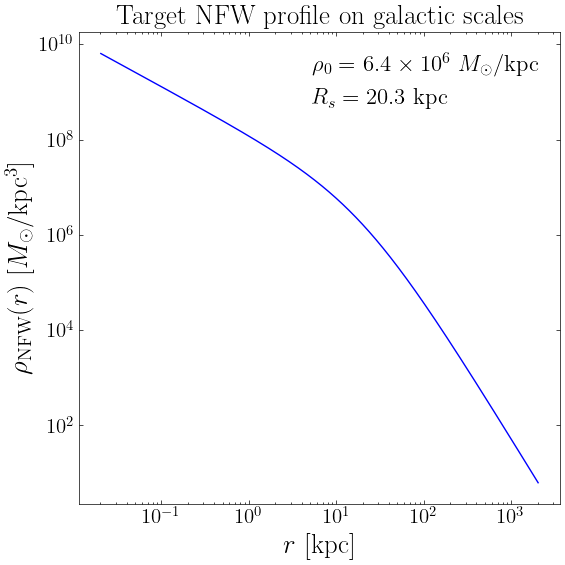

In [4]:
### PARAMETERS OF THE TARGET NFW PROFILE
# Parameters of the profile
rho_0 = 6.4e6   # Msun/kpc3
R_s = 20.3  # kpc

# Profile
rPoints = 1000
rValues = np.logspace(-3, 2, rPoints) * R_s  # kpc
rhoValues = rho_0/(rValues/R_s * (1 + rValues/R_s)**2)    # NFW profile

# Plot
plot_1d_function(rValues, rhoValues, xLabel = r"$r$ [kpc]", yLabel = r"$\rho_\text{NFW}(r)$ [$M_\odot$/kpc$^3$]", 
                xScale="log", yScale="log", textLabels=[r"$\rho_0 = $ {} $M_\odot/$kpc".format(sci_notation(rho_0, 1)), r"$R_s = {:.1f}$ kpc".format(R_s)],
                 titleLabel="Target NFW profile on galactic scales", save = False, saveName="TargetNFW profile.png")

# 2. Radial density profiles of the gravitational atom

We now want to show numerical control of the radial density profiles generated by the different modes of the gravitational atom. We aim to reproduce Figure 2 of Yavetz+2022.

We therefore want to plot $R_{nl}^2(r)$ for the different values of $n$ and $l$.

In [7]:
### PARAMETERS OF THE GRAVITAITONAL ATOM
M = 1e6 # mass of the central black hole - solar masses 
alpha = 0.1  # gravitational fine structure constant - dimensionless
rC = M * Msun/alpha**2 * G/c**2 /(1e3 * pc) # scale radius of the gravitational atom - kpc
mu = calculate_mu(alpha, M) # eV
muSI = mu * eV/c**2   # kg

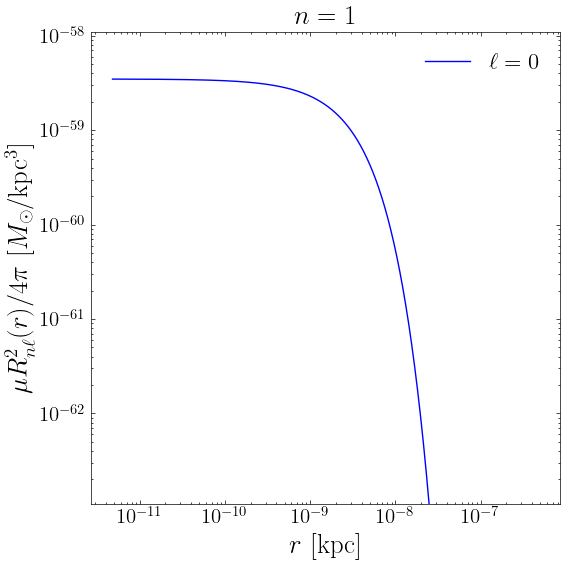

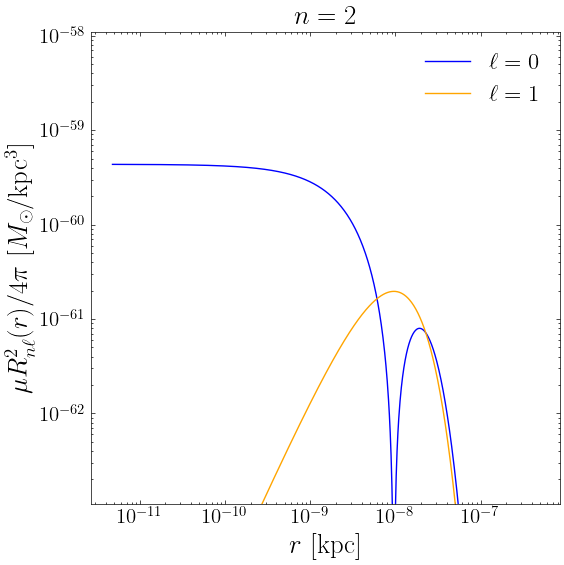

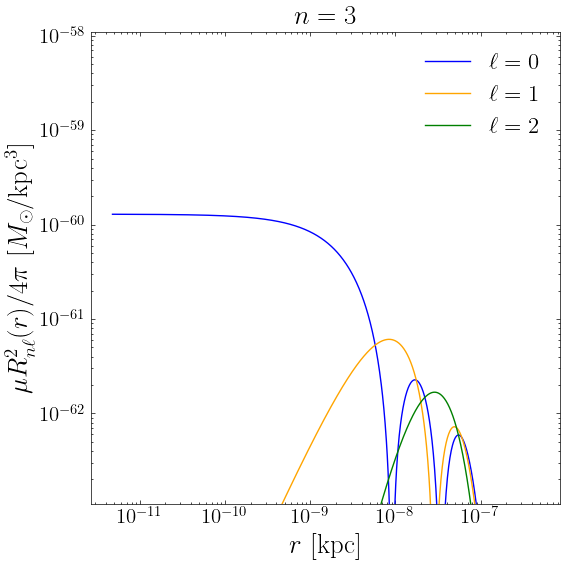

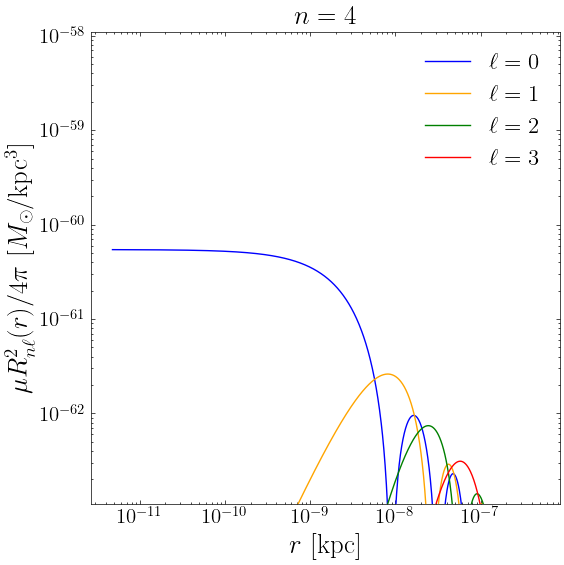

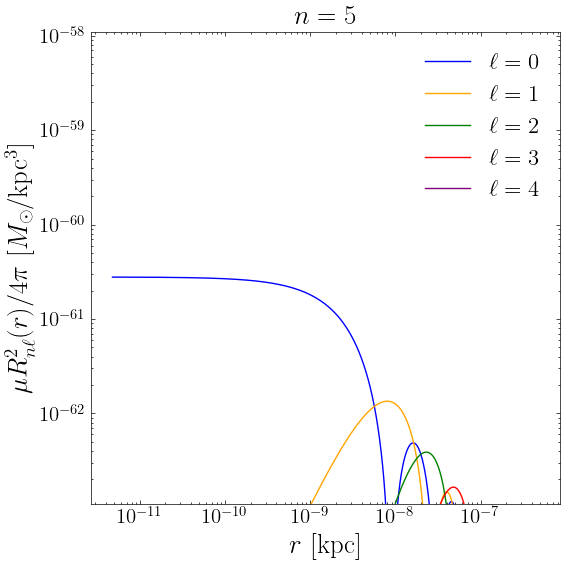

In [9]:
# Radial profiles
rPoints = 1000
r = np.logspace(-3, 2, rPoints) * rC   # radial coordinate - kpc

# n=1
R2_10 = 4/rC**3 * np.exp(-2*r/rC)
# n=2
R2_20 = 1/(8*rC**3) * (2 - r/rC)**2 * np.exp(-r/rC)
R2_21 = 1/(24*rC**3) * (r/rC)**2 * np.exp(-r/rC)
# n=3
R2_30 = 4/(19683*rC**3) * (27 - 18 * r/rC + 2 * (r/rC)**2)**2 * np.exp(-2/3 * r/rC)
R2_31 = 2/(2187*rC**3) * (r/rC)**2 * (4 - 2/3 * r/rC)**2 * np.exp(-2/3 * r/rC)
R2_32 = 8/(98415*rC**3) * (r/rC)**4 * np.exp(-2/3 * r/rC)
# n=4
R2_40 = 1/(589824*rC**3) * (192 - 144 * r/rC + 24 * (r/rC)**2 - (r/rC)**3)**2 * np.exp(-1/2 * r/rC)
R2_41 = 1/(983040*rC**3) * (r/rC)**2 * (80 - 20 * r/rC + (r/rC)**2)**2 * np.exp(-1/2 * r/rC)
R2_42 = 1/(737280*rC**3) * (r/rC)**4 * (6 - 1/2 * r/rC)**2 * np.exp(-1/2 * r/rC)
R2_43 = 1/(20643840*rC**3) * (r/rC)**6 * np.exp(-1/2 * r/rC)
# n=5
R2_50 = 4/(10986328125*rC**3) * (9375 - 7500 * r/rC + 1500 * (r/rC)**2 - 100 * (r/rC)**3 + 2 * (r/rC)**4)**2 * np.exp(-2/5 * r/rC)
R2_51 = 8/(32985984375*rC**3) * (r/rC)**2 * (3750 - 1125 * r/rC + 90 * (r/rC)**2 - 2 * (r/rC)**3)**2 * np.exp(-2/5 * r/rC)
R2_52 = 8/(76904296875*rC**3) * (r/rC)**4 * (525 - 70 * r/rC + 2 * (r/rC)**2)**2 * np.exp(-2/5 * r/rC)
R2_53 = 2/(3076171875*rC**3) * (r/rC)**6 * (8 - 2/5 * r/rC)**2 * np.exp(-2/5 * r/rC)
R2_54 = 8/(692138671875*rC**3) * (r/rC)**8 * np.exp(-2/5 * r/rC)

# Plots
# n=1
# n=1
plot_1d_function([r], [muSI/(Msun*4*pi)*R2_10], plotLabels=[r"$\ell=0$"], xLabel = r"$r$ [kpc]", yLabel = r"$\mu R_{n\ell}^2(r)/4\pi$ [$M_\odot$/kpc$^3$]", 
                 titleLabel="$n=1$", xScale = "log", yScale = "log", yMin = 1e-5 * muSI/Msun * 1/rC**3, yMax = 1 * muSI/Msun * 1/rC**3, 
                 save = False, saveName="radialDensity n=1.png")
# n=2
plot_1d_function([r, r], [muSI/(Msun*4*pi)*R2_20, muSI/(Msun*4*pi)*R2_21], plotLabels=[r"$\ell=0$", r"$\ell=1$"], xLabel = r"$r$ [kpc]", yLabel = r"$\mu R_{n\ell}^2(r)/4\pi$ [$M_\odot$/kpc$^3$]", titleLabel="$n=2$", 
                xScale = "log", yScale = "log", yMin = 1e-5 * muSI/Msun * 1/rC**3, yMax = 1 * muSI/Msun * 1/rC**3, save = False, saveName="radialDensity n=2.png")
# n=3
plot_1d_function([r, r, r], [muSI/(Msun*4*pi)*R2_30, muSI/(Msun*4*pi)*R2_31, muSI/(Msun*4*pi)*R2_32], plotLabels=[r"$\ell=0$", r"$\ell=1$", r"$\ell=2$"], xLabel = r"$r$ [kpc]", yLabel = r"$\mu R_{n\ell}^2(r)/4\pi$ [$M_\odot$/kpc$^3$]", titleLabel="$n=3$", xScale = "log", yScale = "log", yMin = 1e-5 * muSI/Msun * 1/rC**3, yMax = 1 * muSI/Msun * 1/rC**3, save = False, saveName="radialDensity n=3.png")
# n=4
plot_1d_function([r, r, r, r], [muSI/(Msun*4*pi)*R2_40, muSI/(Msun*4*pi)*R2_41, muSI/(Msun*4*pi)*R2_42, muSI/(Msun*4*pi)*R2_43], plotLabels=[r"$\ell=0$", r"$\ell=1$", r"$\ell=2$", r"$\ell=3$"], xLabel = r"$r$ [kpc]", yLabel = r"$\mu R_{n\ell}^2(r)/4\pi$ [$M_\odot$/kpc$^3$]", titleLabel="$n=4$", xScale = "log", yScale = "log", yMin = 1e-5 * muSI/Msun * 1/rC**3, yMax = 1 * muSI/Msun * 1/rC**3, save = False, saveName="radialDensity n=4.png")
# n=5
plot_1d_function([r, r, r, r, r], [muSI/(Msun*4*pi)*R2_50, muSI/(Msun*4*pi)*R2_51, muSI/(Msun*4*pi)*R2_52, muSI/(Msun*4*pi)*R2_53, muSI/(Msun*4*pi)*R2_54], plotLabels=[r"$\ell=0$", r"$\ell=1$", r"$\ell=2$", r"$\ell=3$", r"$\ell=4$"], xLabel = r"$r$ [kpc]", yLabel = r"$\mu R_{n\ell}^2(r)/4\pi$ [$M_\odot$/kpc$^3$]", titleLabel="$n=5$", xScale = "log", yScale = "log", yMin = 1e-5 * muSI/Msun * 1/rC**3, yMax = 1 * muSI/Msun * 1/rC**3, save = False, saveName="radialDensity n=5.png")


See comparison with Fig 2 of https://arxiv.org/abs/2109.06125.

## 2.2 Sum of all contributions for a given $n$

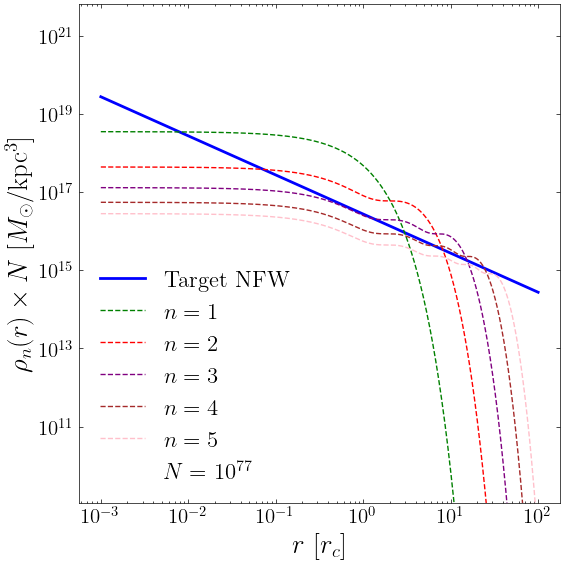

In [17]:
# Radial profiles
r = np.logspace(-3, 2, rPoints) * rC   # radial coordinate - kpc

# n=1
R2_10 = 4/rC**3 * np.exp(-2*r/rC)
R2_1_lists = np.array([R2_10])
# n=2
R2_20 = 1/(8*rC**3) * (2 - r/rC)**2 * np.exp(-r/rC)
R2_21 = 1/(24*rC**3) * (r/rC)**2 * np.exp(-r/rC)
R2_2_lists = np.array([R2_20, R2_21])
# n=3
R2_30 = 4/(19683*rC**3) * (27 - 18 * r/rC + 2 * (r/rC)**2)**2 * np.exp(-2/3 * r/rC)
R2_31 = 2/(2187*rC**3) * (r/rC)**2 * (4 - 2/3 * r/rC)**2 * np.exp(-2/3 * r/rC)
R2_32 = 8/(98415*rC**3) * (r/rC)**4 * np.exp(-2/3 * r/rC)
R2_3_lists = np.array([R2_30, R2_31, R2_32])
# n=4
R2_40 = 1/(589824*rC**3) * (192 - 144 * r/rC + 24 * (r/rC)**2 - (r/rC)**3)**2 * np.exp(-1/2 * r/rC)
R2_41 = 1/(983040*rC**3) * (r/rC)**2 * (80 - 20 * r/rC + (r/rC)**2)**2 * np.exp(-1/2 * r/rC)
R2_42 = 1/(737280*rC**3) * (r/rC)**4 * (6 - 1/2 * r/rC)**2 * np.exp(-1/2 * r/rC)
R2_43 = 1/(20643840*rC**3) * (r/rC)**6 * np.exp(-1/2 * r/rC)
R2_4_lists = np.array([R2_40, R2_41, R2_42, R2_43])
# n=5
R2_50 = 4/(10986328125*rC**3) * (9375 - 7500 * r/rC + 1500 * (r/rC)**2 - 100 * (r/rC)**3 + 2 * (r/rC)**4)**2 * np.exp(-2/5 * r/rC)
R2_51 = 8/(32985984375*rC**3) * (r/rC)**2 * (3750 - 1125 * r/rC + 90 * (r/rC)**2 - 2 * (r/rC)**3)**2 * np.exp(-2/5 * r/rC)
R2_52 = 8/(76904296875*rC**3) * (r/rC)**4 * (525 - 70 * r/rC + 2 * (r/rC)**2)**2 * np.exp(-2/5 * r/rC)
R2_53 = 2/(3076171875*rC**3) * (r/rC)**6 * (8 - 2/5 * r/rC)**2 * np.exp(-2/5 * r/rC)
R2_54 = 8/(692138671875*rC**3) * (r/rC)**8 * np.exp(-2/5 * r/rC)
R2_5_lists = np.array([R2_50, R2_51, R2_52, R2_53, R2_54])

# Sum density profiles over all values of l for given n
radialProfiles = [R2_1_lists, R2_2_lists, R2_3_lists, R2_4_lists, R2_5_lists]
n_star = 5
R2_n_sum = np.array([R2_10 * 0 for i in range(0, n_star)])
for n in range(n_star):
    for l in range(0, n+1):
        R2_n_sum[n] = R2_n_sum[n] + (2*l+1) * radialProfiles[n][l]      # weight factor 2l+1 because of summing over all m  (!!)

lArray = np.array([0, 1, 2, 3, 4])
lFactors = 2*lArray+1

# Re-compute the target profile way closer to the galactic center (cloud length scales) 
rhoTarget = rho_0/(r/R_s * (1 + r/R_s)**2)    # NFW profile


# Hydrogenic functions
factor = 1e77
R2_totalSum = np.zeros_like(r)
for n in range(n_star):
    R2_totalSum = R2_totalSum + R2_n_sum[n]

# Plots
plot_1d_function([r/rC, r/rC, r/rC, r/rC, r/rC, r/rC], 
                 [rhoTarget, muSI/(Msun*4*pi) * R2_n_sum[0] * factor, muSI/(Msun*4*pi) * R2_n_sum[1] * factor,
                 muSI/(Msun*4*pi) * R2_n_sum[2] * factor, muSI/(Msun*4*pi) * R2_n_sum[3] * factor, muSI/(Msun*4*pi) * R2_n_sum[4] * factor], 
                 plotLabels=["Target NFW", "$n=1$", "$n=2$", "$n=3$", "$n=4$", "$n=5$"], 
                 xLabel = r"$r$ [$r_c$]", yLabel = r"$\rho_{n}(r) \times N$ [$M_\odot$/kpc$^3$]", 
                 textLabels=[r"$N = $ {}".format(sci_notation(factor, 0))],
                 titleLabel="", xScale = "log", yScale = "log",
                 LineWidths=[2, 1, 1, 1, 1, 1], LineStyles=['-', '--', '--', '--', '--', '--'],
                 colors = ["blue", "green", "red", "purple", "brown", "pink"],
                 yMin = 1e-10 * muSI/Msun * 1/rC**3 * factor, yMax = 1e15 * rho_0, 
                 save = False, saveName="comp radialDensity total cloud.png")

Preliminary result: Initial population number of the 322 mode is $\sim 10^{77}$. The total number of e-folds to get to $N \sim 10^{200}$ is then $\sim 100$ instead of $\sim 200$. This might open our region in paramter space where coexistence is reasonable.

# 3 Analytical expression for $N_{nlm}$ as function of $n$


We want to have a rough analytical estimation for the occupation number $N_{nlm}$ that needs to multiply each mode $\rho_{n}(r)$ to fit the target NFW profile as best as possible. The total density profile is 

$$\rho_\text{halo}(r) = \sum_n N_{nlm} \rho_{n}(r) \quad \text{ where} \quad  \rho_n(r) = \sum_{l} \rho_{nl} (r) \quad \text{ and} \quad  \rho_{nl}(r) = \sum_m \rho_{nlm}(r) = (2l+1) \mu R_{nl}^2(r)/4\pi$$  

1. Approximate each mode $\rho_{n}(r)$ as a step function, from $r=0$ to $r=r_n$, where $r_n = n(n-1) r_c$ estimated the scale of the mode. This scale is the radial position where the mode $n$ and $l=n-1$ peaks, and

$$r_c = \hbar/c \times  1/\mu\alpha$$

is the scale radius of the cloud.

2. We want this sum of modes $n$ to be as high as the NFW profile at the radius $r_n$. Knowing that for realistic values of $r_c$ and $r_S$ (NFW scale radius), $\rho_\text{NFW} \sim 1/r$, we want the height of our density profile to be

$$\rho_{n}(r_n) = \rho_\text{NFW}(r_c)\frac{1}{n(n-1)}$$

3. The total enclosed mass in this sum of modes $n$ will be

$$ M_n = \rho_{n}(r_n) \times V_n = \rho_\text{NFW}(r_c)\frac{1}{n(n-1)} \times \frac{4\pi}{3} n^3(n-1)^3 r_c^3 = \rho_\text{NFW}(r_c) \times \frac{4\pi}{3} n^2(n-1)^2 r_c^3$$ 


and because there are 

$$\sum_{l=0}^{n-1}(2l + 1) = n^2$$

$n,l,m$ modes per value of $n$, the enclosed mass in each $(n, l, m)$ mode is 

$$ M_{nlm} = \rho_\text{NFW}(r_c) \times \frac{4\pi}{3} (n-1)^2 r_c^3$$ 


4. We can get the estimation for the occupation number $N_{nlm}$ knowing that we can also write the enclosed mass of the $n,l,m$ mode as

$$ M_{nlm} = \int d^3r \ \mu N_{nlm} \frac{R_{nl}^2(r)}{4\pi} = \mu N_{nlm} $$

so that we obtain


$$ N_{nlm} = \frac{M_{nlm}}{\mu} = \frac{\rho_\text{NFW}(r_c)}{\mu} \times \frac{4\pi}{3} (n-1)^2 r_c^3 $$

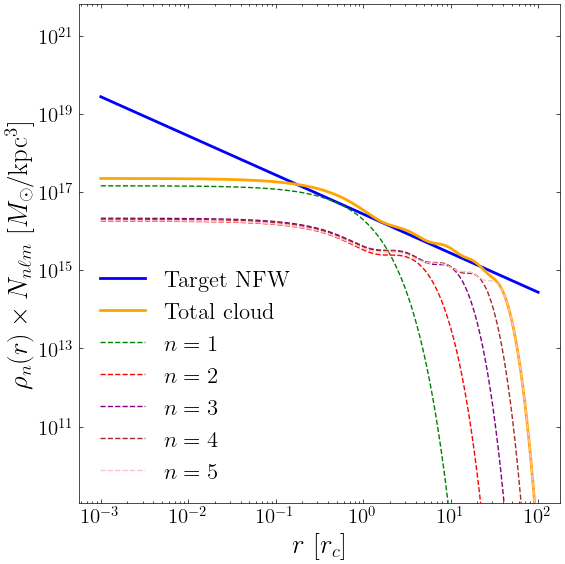

In [13]:
## Analytical estimation of the occupation number

# NFW profile at the scale radius
rcIdx = np.where(np.abs(r/rC - 1) == np.min(np.abs(r/rC - 1)))[0][0]
rhoNFWrC = rhoTarget[rcIdx]    # Msun/kpc3

# μ in solar masses
muSun = muSI/Msun    # Msun

nValues = np.array([1, 2, 3, 4, 5])
occNumb_n = rhoNFWrC/muSun * 4*pi/3 * (nValues-1)**2 * rC**3
occNumb_n[0] = rhoNFWrC/muSun * 4*pi/3 * rC**3   # special case n=1, rn = rc without n-1 factor
# Correction factor to correct our assumption that modes do not overlap. Need factor corrFactor less particles to fit NFW thanks to some overlap between modes.
corrFactor = 2.5
occNumb_n = occNumb_n/corrFactor

## Scaling of the different modes and total
rho_n_analytic = np.zeros_like(R2_n_sum)
# Sum of all rescaled modes
rho_analytic_sum = np.zeros_like(R2_n_sum[0])
for n in range(n_star):
    rho_n_analytic[n] = muSun/4*pi * R2_n_sum[n] * occNumb_n[n]
    rho_analytic_sum = rho_analytic_sum + rho_n_analytic[n]

## Plot
plot_1d_function([r/rC, r/rC, r/rC, r/rC, r/rC, r/rC, r/rC], 
                 [rhoTarget, rho_analytic_sum, rho_n_analytic[0], rho_n_analytic[1], rho_n_analytic[2], rho_n_analytic[3], rho_n_analytic[4]], 
                 plotLabels=["Target NFW", "Total cloud", "$n=1$", "$n=2$", "$n=3$", "$n=4$", "$n=5$"], 
                 xLabel = r"$r$ [$r_c$]", yLabel = r"$\rho_{n}(r) \times N_{n\ell m}$ [$M_\odot$/kpc$^3$]",
                 titleLabel="", xScale = "log", yScale = "log", 
                 LineWidths=[2, 2, 1, 1, 1, 1, 1], LineStyles=['-', '-', '--', '--', '--', '--', '--'],
                 yMin = 1e-10 * muSI/Msun * 1/rC**3 * factor, yMax = 1e15 * rho_0, 
                 save = False, saveName="analytical fit to NFW.png")


In [15]:
## Analytical estimation of the occupation number

# NFW profile at the scale radius
rcIdx = np.where(np.abs(r/rC - 1) == np.min(np.abs(r/rC - 1)))[0][0]
rhoNFWrC = rhoTarget[rcIdx]    # Msun/kpc3

# μ in solar masses
muSun = muSI/Msun    # Msun

nValues = np.array([1, 2, 3, 4, 5])
occNumb_n = rhoNFWrC/muSun * 4*pi/3 * (nValues-1)**2 * rC**3
occNumb_n[0] = rhoNFWrC/muSun * 4*pi/3 * rC**3   # special case n=1, rn = rc without n-1 factor
# Correction factor to correct our assumption that modes do not overlap. Need factor corrFactor less particles to fit NFW thanks to some overlap between modes.
corrFactor = 2.5
occNumb_n = occNumb_n/corrFactor

## Scaling of the different modes and total
rho_n_analytic = np.zeros_like(R2_n_sum)
# Sum of all rescaled modes
rho_analytic_sum = np.zeros_like(R2_n_sum[0])
for n in range(n_star):
    rho_n_analytic[n] = muSun/4*pi * R2_n_sum[n] * occNumb_n[n]
    rho_analytic_sum = rho_analytic_sum + rho_n_analytic[n]


print("The occupation numbers are therefore")
print("\tn\tOccupation Number")
for n in range(n_star):
    print("\t{}\t{:.1e}".format(n, occNumb_n[n]))

print("And are the same for all modes (l, m) for a given value of n.")

The occupation numbers are therefore
	n	Occupation Number
	0	4.2e+74
	1	4.2e+74
	2	1.7e+75
	3	3.8e+75
	4	6.7e+75
And are the same for all modes (l, m) for a given value of n.


#### We conclude that a realistic estimate for the initial occupation number of the $322$ mode is $N_{322, 0} \sim 10^{75}.$